# Notebook 02: Exploration

**Objective:**
Explore class distribution, plot raw signals using `src.visualization`, and understand the dataset.

In [5]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_loader import BUTPPGDataLoader
from src.visualization import plot_signal

DATA_DIR = os.path.join(project_root, 'brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0')
PROCESSED_DIR = os.path.join(project_root, 'processed_data')

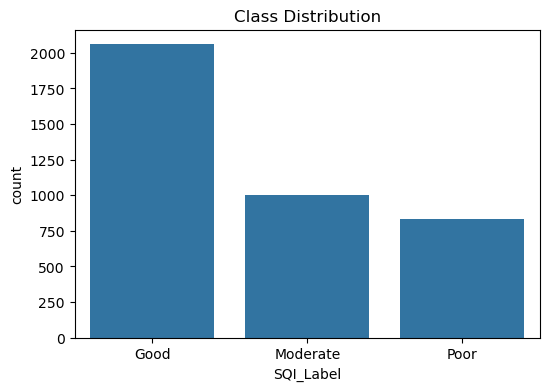

In [6]:
df_labels = pd.read_csv(os.path.join(PROCESSED_DIR, 'labels_3class.csv'))

plt.figure(figsize=(6,4))
sns.countplot(data=df_labels, x='SQI_Label', order=['Good', 'Moderate', 'Poor'])
plt.title('Class Distribution')
plt.show()

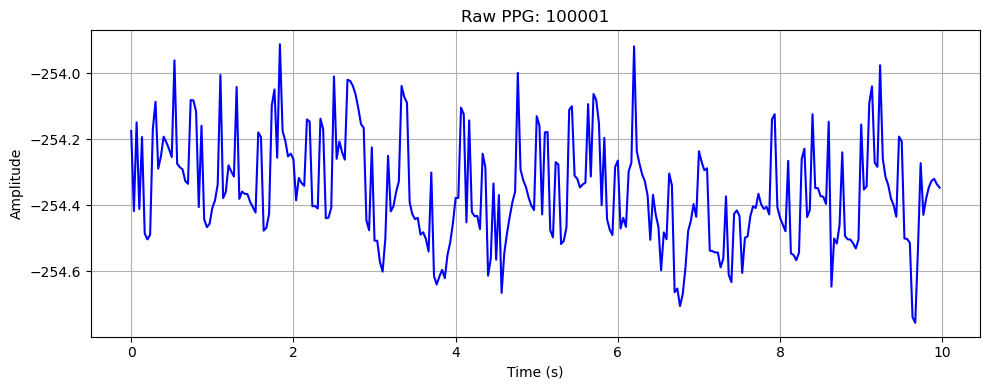

In [7]:
loader = BUTPPGDataLoader(DATA_DIR)
sample_id = str(df_labels['ID'].iloc[0])
raw_sig, _, fs, _ = loader.load_signals(sample_id)

if raw_sig is not None:
    plot_signal(raw_sig, title=f"Raw PPG: {sample_id}", fs=fs)

### Validation Check

In [8]:
print("Labels Shape:", df_labels.shape)
print("Sample Signal Length:", len(raw_sig) if raw_sig is not None else 0)

Labels Shape: (3888, 4)
Sample Signal Length: 300
